<div style="text-align: center; line-height: 1.6; font-family: Arial, sans-serif;">

<h1 style="color:#1f77b4;  margin-bottom: 10px;">DEEP LEARNING</h1>

<h2 style="color:#333333;  margin-bottom: 10px;">Course End Project: <span style="color:#2ca02c;">Lending Club Loan Data Analysis</span></h2>

<h3 style="color:#555555;  margin-bottom: 5px;">By: <span style="font-weight:normal;">Martha Moreno</span></h3>

<h4 style="color:#999999; ">November 2025</h4>

</div>

In [206]:
# importing required libraries
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.utils.class_weight import compute_class_weight
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

from sklearn.metrics import (
    roc_auc_score, roc_curve, precision_recall_curve,
    classification_report, confusion_matrix, average_precision_score
)

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, optimizers
from tensorflow.keras.models import load_model

In [207]:
# plotting defaults
%matplotlib inline
sns.set(style="whitegrid")
pd.options.display.max_columns = 200
pd.options.display.max_rows = 100

In [208]:
# Loading the dataset
DATA_PATH = "data/loan_data.csv"   
assert os.path.exists(DATA_PATH), f"Put the CSV at {DATA_PATH}"

df = pd.read_csv(DATA_PATH)
df.head()

,credit.policy,purpose,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid
0,1,debt_consolidation,0.1189,829.10,11.350407,19.48,737,5639.958333,28854,52.1,0,0,0,0
1,1,credit_card,0.1071,228.22,11.082143,14.29,707,2760.000000,33623,76.7,0,0,0,0
2,1,debt_consolidation,0.1357,366.86,10.373491,11.63,682,4710.000000,3511,25.6,1,0,0,0
3,1,debt_consolidation,0.1008,162.34,11.350407,8.10,712,2699.958333,33667,73.2,1,0,0,0
4,1,credit_card,0.1426,102.92,11.299732,14.97,667,4066.000000,4740,39.5,0,1,0,0


In [209]:
print(df.columns.tolist())

['credit.policy', 'purpose', 'int.rate', 'installment', 'log.annual.inc', 'dti', 'fico', 'days.with.cr.line', 'revol.bal', 'revol.util', 'inq.last.6mths', 'delinq.2yrs', 'pub.rec', 'not.fully.paid']


#FEATURE TRANSFORMATION: Transform categorical values into numerical values (discrete)

In [210]:

# identification of columns: target, numeric and categorical columns

# Target and features
target = 'not.fully.paid'
X = df.drop(columns=[target])

# ensuring the target variable (y) is numeric,
y = df[target].astype(int)

# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(X_train.shape, X_test.shape)


(7662, 13) (1916, 13)


In [211]:
# Creating transformation pipelines

# Identify column types
num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()


# Numerical pipeline: creating an imputer for filling missing values in case new data comes in. Currently there are no missing values in the dataset + scaler (rescaling the data to the same scale)
num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical pipeline: filling missing values + encoding using OneHotEncoder
cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Building a preprocessing pipeline: Combining both pipelines above in a ColumnTransformer
preprocessor = ColumnTransformer(transformers=[
    ('num', num_transformer, num_cols),
    ('cat', cat_transformer, cat_cols)
], remainder='drop')

In [212]:
# Fit on the training data
preprocessor.fit(X_train)

# Transform both train and test data
X_train_trans = preprocessor.transform(X_train)
X_test_trans = preprocessor.transform(X_test)

In [213]:
#Converting to DataFrame

# New feature names
ohe = preprocessor.named_transformers_['cat'].named_steps['onehot']
cat_feature_names = ohe.get_feature_names_out(cat_cols).tolist()
transformed_feature_names = num_cols + cat_feature_names

# Convert transformed arrays into DataFrames

# Training DataFrame
if hasattr(X_train_trans, "toarray"):
    X_train_df = pd.DataFrame(X_train_trans.toarray(), columns=transformed_feature_names, index=X_train.index)
    X_test_df = pd.DataFrame(X_test_trans.toarray(), columns=transformed_feature_names, index=X_test.index)
else:
    X_train_df = pd.DataFrame(X_train_trans, columns=transformed_feature_names, index=X_train.index)
    X_test_df = pd.DataFrame(X_test_trans, columns=transformed_feature_names, index=X_test.index)

print("Transformed training data shape:", X_train_df.shape)
print("Transformed test data shape:", X_test_df.shape)
X_train_df.head()

Transformed training data shape: (7662, 19)
Transformed test data shape: (1916, 19)


,credit.policy,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,purpose_all_other,purpose_credit_card,purpose_debt_consolidation,purpose_educational,purpose_home_improvement,purpose_major_purchase,purpose_small_business
6381,0.491542,0.744534,1.109194,0.696658,0.012171,-0.629324,0.275685,-0.007634,0.951523,-0.262631,1.591971,-0.238688,0.0,1.0,0.0,0.0,0.0,0.0,0.0
7589,0.491542,-1.779946,-0.795226,0.174696,0.017975,0.689102,0.234302,-0.156335,-0.150797,-0.726077,-0.302667,-0.238688,0.0,1.0,0.0,0.0,0.0,0.0,0.0
465,0.491542,-0.912273,-0.889878,-0.252212,-0.101001,0.161732,0.699294,0.078160,-0.339668,-0.726077,1.591971,-0.238688,0.0,0.0,1.0,0.0,0.0,0.0,0.0
5343,0.491542,0.486476,0.096296,1.097154,0.506940,-0.629324,-0.493588,-0.456364,0.086150,-0.262631,-0.302667,-0.238688,1.0,0.0,0.0,0.0,0.0,0.0,0.0
8016,-2.034412,0.318178,0.576044,1.172312,-0.333151,-1.288536,-1.555593,-0.503080,-1.613689,1.127705,-0.302667,-0.238688,0.0,0.0,1.0,0.0,0.0,0.0,0.0


# Exploratory Data Analysis (EDA)

In [214]:
# Displaying basic information about the dataset
print("Dataset shape:", df.shape)
print("\nData types:\n", df.dtypes)
print("\nMissing values per column:\n", df.isnull().sum())

# Statistical summary
print("\nNumerical summary:\n")
display(df[num_cols].describe())

Dataset shape: (9578, 14)

Data types:
 credit.policy          int64
purpose               object
int.rate             float64
installment          float64
log.annual.inc       float64
dti                  float64
fico                   int64
days.with.cr.line    float64
revol.bal              int64
revol.util           float64
inq.last.6mths         int64
delinq.2yrs            int64
pub.rec                int64
not.fully.paid         int64
dtype: object

Missing values per column:
 credit.policy        0
purpose              0
int.rate             0
installment          0
log.annual.inc       0
dti                  0
fico                 0
days.with.cr.line    0
revol.bal            0
revol.util           0
inq.last.6mths       0
delinq.2yrs          0
pub.rec              0
not.fully.paid       0
dtype: int64

Numerical summary:



,credit.policy,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec
count,9578.000000,9578.000000,9578.000000,9578.000000,9578.000000,9578.000000,9578.000000,9.578000e+03,9578.000000,9578.000000,9578.000000,9578.000000
mean,0.804970,0.122640,319.089413,10.932117,12.606679,710.846314,4560.767197,1.691396e+04,46.799236,1.577469,0.163708,0.062122
std,0.396245,0.026847,207.071301,0.614813,6.883970,37.970537,2496.930377,3.375619e+04,29.014417,2.200245,0.546215,0.262126
min,0.000000,0.060000,15.670000,7.547502,0.000000,612.000000,178.958333,0.000000e+00,0.000000,0.000000,0.000000,0.000000
25%,1.000000,0.103900,163.770000,10.558414,7.212500,682.000000,2820.000000,3.187000e+03,22.600000,0.000000,0.000000,0.000000
50%,1.000000,0.122100,268.950000,10.928884,12.665000,707.000000,4139.958333,8.596000e+03,46.300000,1.000000,0.000000,0.000000
75%,1.000000,0.140700,432.762500,11.291293,17.950000,737.000000,5730.000000,1.824950e+04,70.900000,2.000000,0.000000,0.000000
max,1.000000,0.216400,940.140000,14.528354,29.960000,827.000000,17639.958330,1.207359e+06,119.000000,33.000000,13.000000,5.000000


In [215]:
# Description of the data
display(df.info())
display(df.describe(include='all').T)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9578 entries, 0 to 9577
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   credit.policy      9578 non-null   int64  
 1   purpose            9578 non-null   object 
 2   int.rate           9578 non-null   float64
 3   installment        9578 non-null   float64
 4   log.annual.inc     9578 non-null   float64
 5   dti                9578 non-null   float64
 6   fico               9578 non-null   int64  
 7   days.with.cr.line  9578 non-null   float64
 8   revol.bal          9578 non-null   int64  
 9   revol.util         9578 non-null   float64
 10  inq.last.6mths     9578 non-null   int64  
 11  delinq.2yrs        9578 non-null   int64  
 12  pub.rec            9578 non-null   int64  
 13  not.fully.paid     9578 non-null   int64  
dtypes: float64(6), int64(7), object(1)
memory usage: 1.0+ MB


None

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
credit.policy,9578.0,NaN,NaN,NaN,0.80497,0.396245,0.0,1.0,1.0,1.0,1.0
purpose,9578,7,debt_consolidation,3957,NaN,NaN,NaN,NaN,NaN,NaN,NaN
int.rate,9578.0,NaN,NaN,NaN,0.12264,0.026847,0.06,0.1039,0.1221,0.1407,0.2164
installment,9578.0,NaN,NaN,NaN,319.089413,207.071301,15.67,163.77,268.95,432.7625,940.14
log.annual.inc,9578.0,NaN,NaN,NaN,10.932117,0.614813,7.547502,10.558414,10.928884,11.291293,14.528354
dti,9578.0,NaN,NaN,NaN,12.606679,6.88397,0.0,7.2125,12.665,17.95,29.96
fico,9578.0,NaN,NaN,NaN,710.846314,37.970537,612.0,682.0,707.0,737.0,827.0
days.with.cr.line,9578.0,NaN,NaN,NaN,4560.767197,2496.930377,178.958333,2820.0,4139.958333,5730.0,17639.95833
revol.bal,9578.0,NaN,NaN,NaN,16913.963876,33756.189557,0.0,3187.0,8596.0,18249.5,1207359.0
revol.util,9578.0,NaN,NaN,NaN,46.799236,29.014417,0.0,22.6,46.3,70.9,119.0


In [216]:
# Checking for class imbalance
print(df['not.fully.paid'].value_counts(), '\n')

not.fully.paid
0    8045
1    1533
Name: count, dtype: int64 



In [217]:
# Checking for class imbalance in percentage
print(df['not.fully.paid'].value_counts(normalize=True))

not.fully.paid
0    0.839946
1    0.160054
Name: proportion, dtype: float64


# Additional Feature Engineering

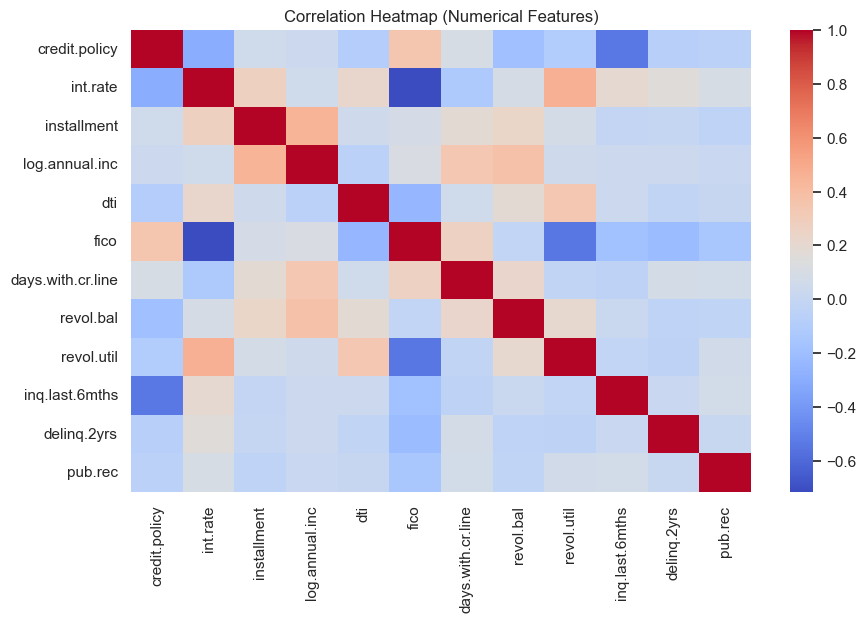

In [218]:
# Checking correlation between features 
plt.figure(figsize=(10, 6))
sns.heatmap(df[num_cols].corr(), cmap='coolwarm', annot=False)
plt.title('Correlation Heatmap (Numerical Features)')
plt.show()

In [219]:
#Identifying highly correlated features and removing features with a correlation coefficient > 0.7

# Compute correlation matrix for numerical columns
corr_matrix = df[num_cols].corr().abs()

# Selecting upper triangle of correlation matrix
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Find features with correlation > 0.8
to_drop = [column for column in upper.columns if any(upper[column] > 0.7)]

print("Highly correlated features to drop:\n", to_drop)

Highly correlated features to drop:
 ['fico']


In [220]:
# Dropping correlated features from the training and test sets
X_train_reduced = X_train_df.drop(columns=to_drop, errors='ignore')
X_test_reduced = X_test_df.drop(columns=to_drop, errors='ignore')

print("Shape before:", X_train_df.shape)
print("Shape after removing correlated features:", X_train_reduced.shape)

Shape before: (7662, 19)
Shape after removing correlated features: (7662, 18)


# Modeling

# - Baseline: Logistic Regression

In [221]:
lr = LogisticRegression(max_iter=2000, class_weight='balanced')
lr.fit(X_train_reduced, y_train)

y_pred_lr = lr.predict(X_test_reduced)
y_proba_lr = lr.predict_proba(X_test_reduced)[:, 1]

print("Logistic Regression classification report:")
print(classification_report(y_test, y_pred_lr, digits=4))
print("ROC AUC:", roc_auc_score(y_test, y_proba_lr).round(4))

Logistic Regression classification report:
              precision    recall  f1-score   support

           0     0.8875    0.6818    0.7712      1609
           1     0.2471    0.5472    0.3404       307

    accuracy                         0.6602      1916
   macro avg     0.5673    0.6145    0.5558      1916
weighted avg     0.7849    0.6602    0.7022      1916

ROC AUC: 0.6767


# - Keras/TensorFlow

In [222]:
#Preparing data for Keras

# Convert to numpy arrays and float32 for Keras
X_tr = X_train_reduced.values.astype(np.float32)
X_te = X_test_reduced.values.astype(np.float32)
y_tr = y_train.values.astype(np.float32)
y_te = y_test.values.astype(np.float32)

from sklearn.utils import class_weight
classes = np.unique(y_tr)
cw = class_weight.compute_class_weight(class_weight='balanced', classes=classes, y=y_tr)
class_weights = {int(c): float(w) for c, w in zip(classes, cw)}
print("Class weights:", class_weights)


Class weights: {0: 0.5952454940957116, 1: 3.124796084828711}


In [223]:
# Building Keras Model

def build_model(input_dim):
    inp = layers.Input(shape=(input_dim,))
    x = layers.Dense(128, activation='relu')(inp)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(64, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.2)(x)
    x = layers.Dense(32, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.2)(x)
    out = layers.Dense(1, activation='sigmoid')(x)
    model = models.Model(inputs=inp, outputs=out)
    return model

model = build_model(X_tr.shape[1])
model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['AUC', 'accuracy']
)

model.summary()

Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 18)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 128)            │         2,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_18          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_19          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_20          │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,697 (53.50 KB)

 Trainable params: 13,249 (51.75 KB)

 Non-trainable params: 448 (1.75 KB)

In [224]:
# Defining callbacks
es = callbacks.EarlyStopping(monitor='AUC', patience=10, mode='max',
                             restore_best_weights=True, verbose=1)
rlr = callbacks.ReduceLROnPlateau(monitor='AUC', factor=0.5, patience=5,
                                  mode='max', verbose=1)



In [225]:
# Training the model
history = model.fit(
    X_tr, y_tr,
    validation_split=0.15,
    epochs=50,                 
    batch_size=256,
    callbacks=[es, rlr],       
    class_weight=class_weights,
    verbose=2
)


Epoch 1/50
26/26 - 3s - 107ms/step - AUC: 0.5647 - accuracy: 0.5267 - loss: 0.8179 - val_AUC: 0.6337 - val_accuracy: 0.5757 - val_loss: 0.6864 - learning_rate: 0.0010
Epoch 2/50
26/26 - 0s - 5ms/step - AUC: 0.6099 - accuracy: 0.5746 - loss: 0.7409 - val_AUC: 0.6485 - val_accuracy: 0.4843 - val_loss: 0.7024 - learning_rate: 0.0010
Epoch 3/50
26/26 - 0s - 5ms/step - AUC: 0.6344 - accuracy: 0.5814 - loss: 0.7004 - val_AUC: 0.6490 - val_accuracy: 0.4635 - val_loss: 0.7126 - learning_rate: 0.0010
Epoch 4/50
26/26 - 0s - 5ms/step - AUC: 0.6489 - accuracy: 0.5974 - loss: 0.6824 - val_AUC: 0.6457 - val_accuracy: 0.4817 - val_loss: 0.7213 - learning_rate: 0.0010
Epoch 5/50
26/26 - 0s - 5ms/step - AUC: 0.6414 - accuracy: 0.6012 - loss: 0.6879 - val_AUC: 0.6546 - val_accuracy: 0.4817 - val_loss: 0.7276 - learning_rate: 0.0010
Epoch 6/50
26/26 - 0s - 4ms/step - AUC: 0.6441 - accuracy: 0.5911 - loss: 0.6860 - val_AUC: 0.6592 - val_accuracy: 0.5000 - val_loss: 0.7245 - learning_rate: 0.0010
Epoch 7/

In [226]:
# Explicitly save the trained model
model.save('best_loan_model.keras')
print("Model saved. File exists?", os.path.exists('best_loan_model.keras'))


Model saved. File exists? True


In [227]:
# Loading the saved model
best_model = load_model('best_loan_model.keras')

In [228]:
# Making predictions
y_proba = best_model.predict(X_te).ravel()          # probabilities
y_pred = (y_proba >= 0.5).astype(int)             # binary labels

60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


In [229]:
# Evaluate metrics
print("Accuracy:", accuracy_score(y_te, y_pred))
print("Precision:", precision_score(y_te, y_pred).round(4))
print("Recall:", recall_score(y_te, y_pred).round(4))
print("F1 Score:", f1_score(y_te, y_pred).round(4))
print("ROC AUC:", roc_auc_score(y_te, y_proba).round(4))
print("\nConfusion Matrix:\n", confusion_matrix(y_te, y_pred))

Accuracy: 0.6096033402922756
Precision: 0.2314
Recall: 0.6189
F1 Score: 0.3369
ROC AUC: 0.6749

Confusion Matrix:
 [[978 631]
 [117 190]]


In [230]:
#Printing some predictions
n = 10  # number of predictions to show
print("First", n, "predicted probabilities:")
print(y_proba[:n])

print("\nFirst", n, "binary predictions:")
print(y_pred[:n])

First 10 predicted probabilities:
[0.66906077 0.32976514 0.44352025 0.60456526 0.4605703  0.8241852
 0.76249194 0.34816262 0.39649314 0.6780631 ]

First 10 binary predictions:
[1 0 0 1 0 1 1 0 0 1]


In [231]:
# Combine into a DataFrame 
results_df = pd.DataFrame({
    'Actual': y_test,            
    'Predicted_Prob': y_proba,
    'Predicted_Class': y_pred
})

print(results_df.head(10))  

      Actual  Predicted_Prob  Predicted_Class
8157       0        0.669061                1
1928       0        0.329765                0
2779       0        0.443520                0
2520       0        0.604565                1
2601       1        0.460570                0
9184       0        0.824185                1
8884       0        0.762492                1
7696       1        0.348163                0
8067       0        0.396493                0
809        0        0.678063                1


# Comparison Logistic Regression with Keras/TensorFlow

In [232]:
# Logistic Regression metrics
metrics_lr = {
    "Accuracy": accuracy_score(y_test, y_pred_lr),
    "Precision": precision_score(y_test, y_pred_lr).round(4),
    "Recall": recall_score(y_test, y_pred_lr).round(4),
    "F1": f1_score(y_test, y_pred_lr).round(4),
    "ROC AUC": roc_auc_score(y_test, y_proba_lr).round(4)
}

# Keras model metrics
metrics_keras = {
    "Accuracy": accuracy_score(y_te, y_pred),
    "Precision": precision_score(y_te, y_pred).round(4),
    "Recall": recall_score(y_te, y_pred).round(4),
    "F1": f1_score(y_te, y_pred).round(4),
    "ROC AUC": roc_auc_score(y_te, y_proba).round(4)
}

In [233]:
comparison_df = pd.DataFrame({
    "Metric": list(metrics_lr.keys()),
    "Logistic Regression": list(metrics_lr.values()),
    "Keras Model": list(metrics_keras.values())
})

print(comparison_df)

      Metric  Logistic Regression  Keras Model
0   Accuracy              0.66023     0.609603
1  Precision              0.24710     0.231400
2     Recall              0.54720     0.618900
3         F1              0.34040     0.336900
4    ROC AUC              0.67670     0.674900
